<div class = "alert alert-info"> 
    <span style="font-family: 'Times New Roman'; font-size: 16px;">
    <h1 align = center> <b> A Listwise Approach for Dynamic Asset Selection </b> </h1>
    <h2 align = center> <font color = grey> .... </font> </h2>
    </span>
</div>

<span style="font-family: 'Times New Roman'; font-size: 16px;">

<h3> <b> Description </b> </h3>

Dans ce projet, nous allons  implémenter une approche avancée et innovante pour le ranking d'actions en fonction de leur attractivité, mesurée par leur potentiel de performance future. Nous nous appuyons sur une méthodologie de learning-to-rank (spécifiquement ListNet), qui est une technique de machine learning listwise permettant d'apprendre à classer des listes d'éléments de manière optimale, plutôt que de prédire des valeurs individuelles comme dans les modèles traditionnels. Cela le distingue des stratégies factorielles classiques (e.g., Fama-French), qui utilisent souvent des régressions linéaires ou des scores additifs pour sélectionner des actifs.

Cette approche pouurait être employé pour: l'optimisation de portefeuille (e.g., sélection top-k actions pour long-only), gestion dynamique (rebalancing mensuel), et remplacement de stratégies passives par une active apprenante.

</span>

<span style="font-family: 'Times New Roman'; font-size: 16px;">

<h3> <b> Données </b> </h3>

Nous allons travailler en utilisant comme univers le CAC40. Les données (prix historiques, etc) seront téléchargées en utilisant l'API yahoo finance. A partir de ces données historiques, nous construirons de nouvelles variables (features) qui serviront de variables explicatives pour notre modèle. 

</br></br>



| **Feature**    | **Description détaillée**                                                                                                        | **Utilité pour le projet**                                                                                                  |
| -------------- | -------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **Momentum**   | Mesure la performance passée d’un actif sur une période donnée (ex : 12 mois – 1 mois) pour capturer les tendances persistantes. | Identifier les actions avec la plus forte probabilité de surperformance future (signal directionnel principal du modèle).   |
| **Volatilité** | Mesure de la dispersion des rendements (historique ou réalisée sur 20, 60, 120 jours, 1 an).                                           | Filtrer les actifs selon le régime de marché et ajuster la confiance des signaux (réduction du bruit).                      |
| **Beta 1 an**  | Sensibilité d’un actif aux mouvements du marché (corrélation + volatilité relative par rapport à un indice).                     | Contrôler l’exposition au risque systématique et réduire les biais liés aux mouvements de marché globaux.                   |
| **Volume**     | Nombre d’actions échangées sur une période (généralement moyenne 20 jours).                                                      | Mesure de liquidité permettant d’éviter les titres difficiles à trader (réduction du slippage et des coûts de transaction). |
| **ADX**        | Indicateur de tendance (Average Directional Index) mesurant la force d’un mouvement haussier ou baissier.                        | Séparer les tendances fortes du bruit de marché et améliorer la fiabilité du signal momentum.                               |
| **Regime**     | Probabilité que l'actif soit dans un régime de haute volatilité    |       Permet d'identifier les phases de hausse et de basse volatilité|



La variable cible que nous allons utiliser pour le ranking est la **rentabilité de l'actif du mois suivant**. Les actions seront donc classées selon leur **potentiel de performance du mois à venir**.

</span>

<span style="font-family: 'Times New Roman'; font-size: 16px;">

<h3> <b> Librairies et configurations globales</b> </h3>

</span>

In [1]:

import os
import random
from data_loading import *
from utility_metrics import *
from listnet_model import *
from train_evaluate_listnet import *
from graphiques_eval import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---------------------------
# Config
# ---------------------------
DATA_PATH = "cac40_full_db_2010_2025.csv"
OUT_DIR = "listnet_results"
os.makedirs(OUT_DIR, exist_ok=True)


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURE_COLS = ['Momentum', 'Volatilite', 'Regime', 'Beta', 'Avg_Volume', 'ADX']
TARGET_COL = 'cible'

BATCH_SIZE = 1
EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 8
CLIP_GRAD = 5.0

NDCG_K = 5
TOP_K = 5
BEST_MODEL_PATH = os.path.join(OUT_DIR, "listnet_best.pth")
RESULTS_PICKLE = os.path.join(OUT_DIR, "results.pkl")

<span style="font-family: 'Times New Roman'; font-size: 16px;">

<h3> <b> Data Preprocessing </b> </h3>

</span>

In [3]:
# ---------------------------
# Main run
# ---------------------------

print(f"Device: {DEVICE}")
print("Loading data...")
train_df, val_df, test_df = load_and_split(DATA_PATH, FEATURE_COLS, TARGET_COL)

# Build scalers on train groups
print("Preparing scalers on training data (2010-2018)...")
# collect numpy arrays per group
train_groups = []
for date, group in train_df.groupby('date'):
    group_sorted = group.sort_values('ticker')
    train_groups.append(group_sorted[FEATURE_COLS].values.astype(np.float32))

scaler = GroupScaler()
scaler.fit(train_groups)

Device: cpu
Loading data...
Preparing scalers on training data (2010-2018)...


In [4]:
# transform features in all sets
def transform_df(df_):
    rows = []
    for date, group in df_.groupby('date'):
        group_sorted = group.sort_values('ticker').copy()
        X = group_sorted[FEATURE_COLS].values.astype(np.float32)
        if X.shape[0] == 0:
            continue
        X_scaled = scaler.transform(X)
        group_sorted.loc[:, FEATURE_COLS] = X_scaled
        rows.append(group_sorted)
    if rows:
        return pd.concat(rows, ignore_index=True)
    else:
        return pd.DataFrame(columns=df_.columns)

train_df_scaled = transform_df(train_df)
val_df_scaled = transform_df(val_df)
test_df_scaled = transform_df(test_df)

In [5]:
# Datasets & loaders
train_ds = ListNetDataset(train_df_scaled, FEATURE_COLS, TARGET_COL)
val_ds = ListNetDataset(val_df_scaled, FEATURE_COLS, TARGET_COL)
test_ds = ListNetDataset(test_df_scaled, FEATURE_COLS, TARGET_COL)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train groups: {len(train_ds)}, Val groups: {len(val_ds)}, Test groups: {len(test_ds)}")

Train groups: 108, Val groups: 12, Test groups: 59


<span style="font-family: 'Times New Roman'; font-size: 16px;">

<h3> <b> Modélisation </b> </h3>

</span>

In [6]:
# Model, optimizer, scheduler
model = ListNetModel(input_dim=len(FEATURE_COLS), hidden_dims=(128, 64), dropout=0.25)  #(128, 64)
model.to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# Cosine scheduler as example
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS))

# Train
print("Starting training...")
history = train_loop(model, optimizer, scheduler, train_loader, val_loader, DEVICE,
                                      epochs=EPOCHS, patience=PATIENCE, clip_grad=CLIP_GRAD)

# Load best model checkpoint
if os.path.exists(BEST_MODEL_PATH):
    print("Loading best model from checkpoint...")
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    print("Warning: no checkpoint found; using current model weights for final evaluation.")


Starting training...


Epoch 1 | Train loss avg: 3.580400 | Val NDCG@5: 0.116516 | groups val: 12 | elapsed: 0.5s
  -> New best model saved (Val NDCG 0.116516) at epoch 1


Epoch 2 | Train loss avg: 3.509860 | Val NDCG@5: -0.283028 | groups val: 12 | elapsed: 1.1s
  No improvement for 1 epoch(s).


Epoch 3 | Train loss avg: 3.524004 | Val NDCG@5: 0.020929 | groups val: 12 | elapsed: 1.7s
  No improvement for 2 epoch(s).


Epoch 4 | Train loss avg: 3.512105 | Val NDCG@5: -0.208977 | groups val: 12 | elapsed: 2.2s
  No improvement for 3 epoch(s).


Epoch 5 | Train loss avg: 3.493700 | Val NDCG@5: -0.151781 | groups val: 12 | elapsed: 2.8s
  No improvement for 4 epoch(s).


Epoch 6 | Train loss avg: 3.473698 | Val NDCG@5: -0.348142 | groups val: 12 | elapsed: 3.3s
  No improvement for 5 epoch(s).


Epoch 7 | Train loss avg: 3.509056 | Val NDCG@5: -0.262914 | groups val: 12 | elapsed: 3.8s
  No improvement for 6 epoch(s).


Epoch 8 | Train loss avg: 3.460275 | Val NDCG@5: -0.290853 | groups val: 12 | elapsed: 4.3s
  No improvement for 7 epoch(s).


Epoch 9 | Train loss avg: 3.488305 | Val NDCG@5: -0.325091 | groups val: 12 | elapsed: 4.9s
  No improvement for 8 epoch(s).
Early stopping triggered after 9 epochs (best epoch: 1, best val NDCG: 0.116516)
Training finished in 4.9s. Best val NDCG@5: 0.116516 at epoch 1
Loading best model from checkpoint...


In [7]:
# Final evaluation on test set (2020-2024)
print("Final evaluation on test set (2020-2024)...")
test_metrics, collected = evaluate_model(model, optimizer, test_loader, DEVICE, k_ndcg=NDCG_K, topk=TOP_K)

# build group level table
def create_group_level_table_local(all_scores, all_true, all_dates, all_tickers):
    rows = []
    for scores, y_true, date, tickers in zip(all_scores, all_true, all_dates, all_tickers):
        rank_true = np.argsort(np.argsort(-y_true))
        rank_pred = np.argsort(np.argsort(-scores))
        for t, yt, yp, rt, rp in zip(tickers, y_true, scores, rank_true, rank_pred):
            rows.append({"date": date, "ticker": t, "true_return": float(yt), "predicted_score": float(yp), "true_rank": int(rt), "predicted_rank": int(rp)})
    return pd.DataFrame(rows)

group_table = create_group_level_table_local(collected['all_scores'], collected['all_true'], collected['all_dates'], collected['all_tickers'])
group_table['date'] = group_table['date'].apply(lambda x: x[2:12]) 
group_table['ticker'] = group_table['ticker'].apply(lambda x: x[0])

# collect results dict
results_dict = {
    'history': history,
    'test_metrics': test_metrics,
    'collected': collected,
    'group_table': group_table
}

Final evaluation on test set (2020-2024)...


In [8]:
print("=== Test results (2020-2024) ===")
print(f"Groups tested: {test_metrics['n_groups']}")
print(f"Mean NDCG@{NDCG_K}: {test_metrics['ndcg_mean']:.6f}")
print(f"Mean Top-{TOP_K} Accuracy: {test_metrics['topk_mean']:.6f}")
print(f"Mean Spearman: {test_metrics['spearman_mean']:.6f}")

# Example: show topk for last 5 test dates
print("\nSample top-k predictions (last 5 test dates):")
# iterate through last 5 groups in test_ds
n_show = 5
for i in range(max(0, len(test_ds) - n_show), len(test_ds)):
    X, y, tickers, date = test_ds[i]
    X = X.to(DEVICE)
    with torch.no_grad():
        scores = model(X).cpu().numpy()
    order_pred = np.argsort(-scores)
    order_true = np.argsort(-y.numpy())
    top_pred = [tickers[idx] for idx in order_pred[:TOP_K]]
    top_true = [tickers[idx] for idx in order_true[:TOP_K]]
    print(f"{pd.to_datetime(date).date()} | Top pred: {top_pred} | Top true: {top_true}")

print(f"\nBest validation NDCG (saved): {history['best_ndcg']:.6f} at epoch {history['best_epoch']}")
print(f"Model checkpoint: {BEST_MODEL_PATH}")

=== Test results (2020-2024) ===
Groups tested: 59
Mean NDCG@5: -0.861751
Mean Top-5 Accuracy: 0.196610
Mean Spearman: 0.004701

Sample top-k predictions (last 5 test dates):
2024-07-31 | Top pred: ['TEP.PA', 'URW.PA', 'RNO.PA', 'ERF.PA', 'SGO.PA'] | Top true: ['ENGI.PA', 'RMS.PA', 'AC.PA', 'SAN.PA', 'CS.PA']
2024-08-31 | Top pred: ['TEP.PA', 'URW.PA', 'RNO.PA', 'SU.PA', 'ERF.PA'] | Top true: ['MT.AS', 'ERF.PA', 'URW.PA', 'SAF.PA', 'RI.PA']
2024-09-30 | Top pred: ['TEP.PA', 'STLAP.PA', 'RNO.PA', 'URW.PA', 'EDEN.PA'] | Top true: ['GLE.PA', 'RNO.PA', 'AC.PA', 'AIR.PA', 'TEP.PA']
2024-10-31 | Top pred: ['TEP.PA', 'URW.PA', 'EDEN.PA', 'RNO.PA', 'GLE.PA'] | Top true: ['EL.PA', 'MT.AS', 'SAF.PA', 'EDEN.PA', 'AIR.PA']
2024-11-30 | Top pred: ['TEP.PA', 'EDEN.PA', 'URW.PA', 'SGO.PA', 'AC.PA'] | Top true: ['RNO.PA', 'RMS.PA', 'MC.PA', 'GLE.PA', 'KER.PA']

Best validation NDCG (saved): 0.116516 at epoch 1
Model checkpoint: listnet_results\listnet_best.pth


<span style="font-family: 'Times New Roman'; font-size: 16px;">

<h3> <b> Graphiques </b> </h3>

</span>

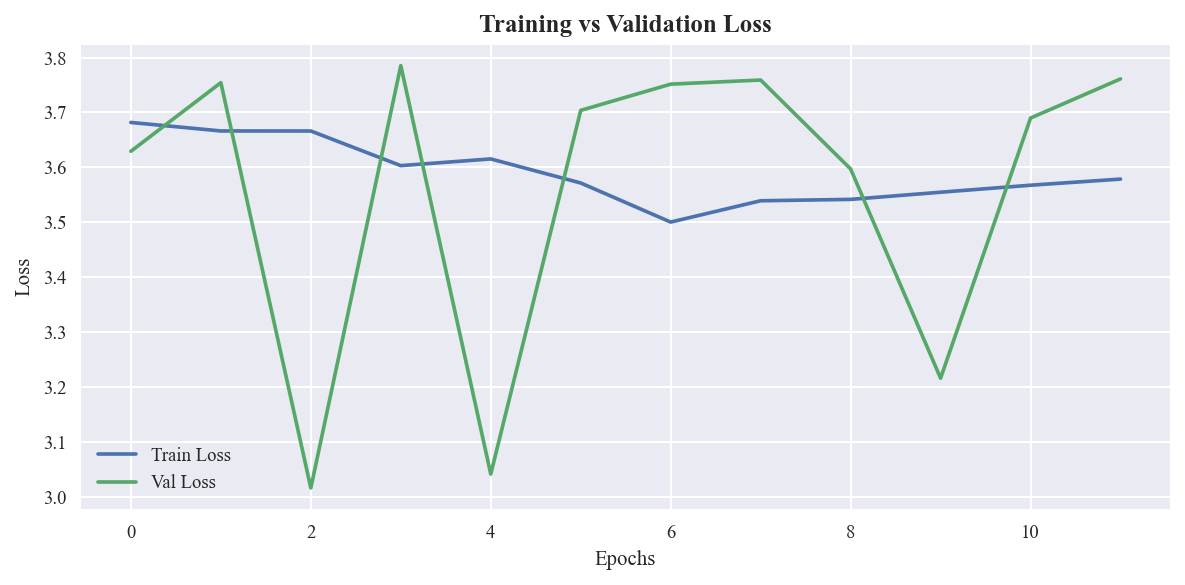

In [9]:
# produce plots
plot_loss_curves(history['train_losses'], history['val_losses'])   

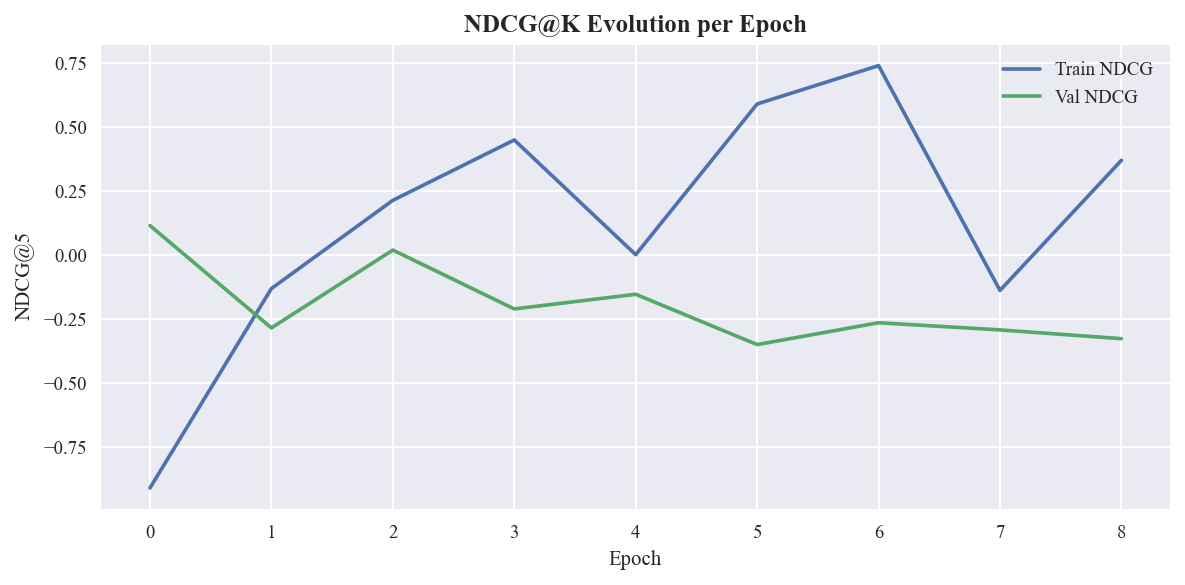

In [10]:
plot_ndcg_by_epoch(history['train_ndcgs'], history['val_ndcgs']) 

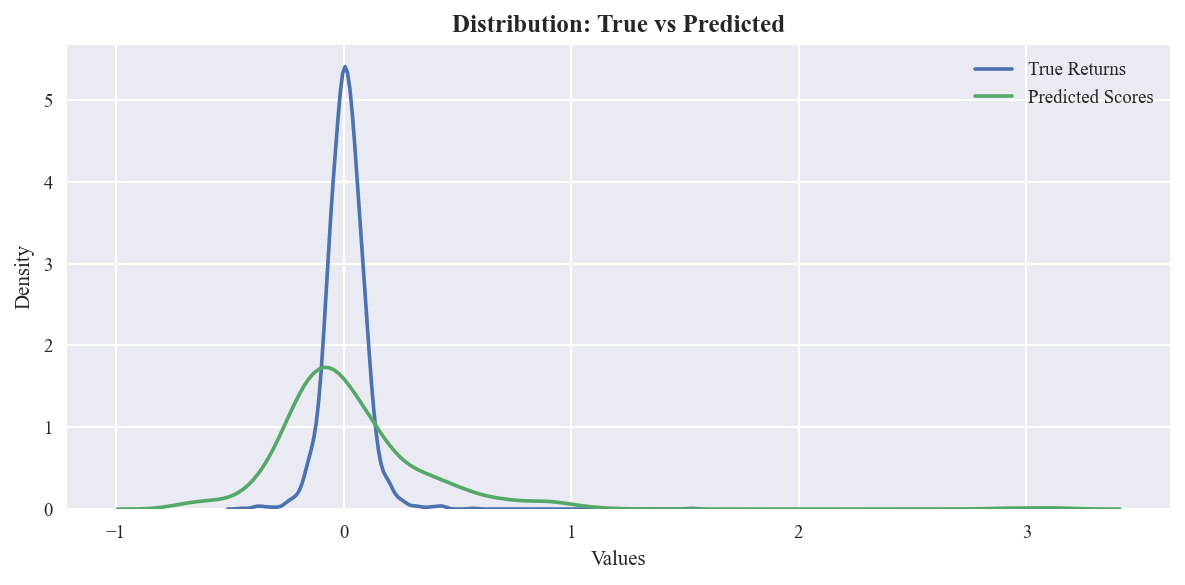

In [11]:
plot_distribution_true_pred(collected['all_true'], collected['all_scores'])  

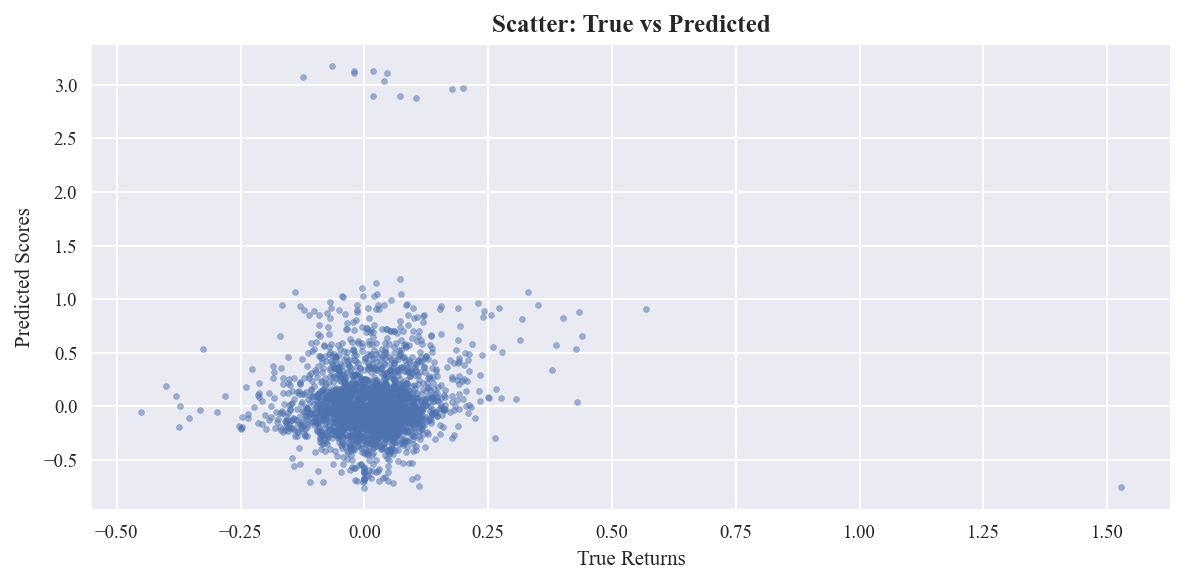

In [12]:
plot_true_vs_pred_scatter(collected['all_true'], collected['all_scores'])  

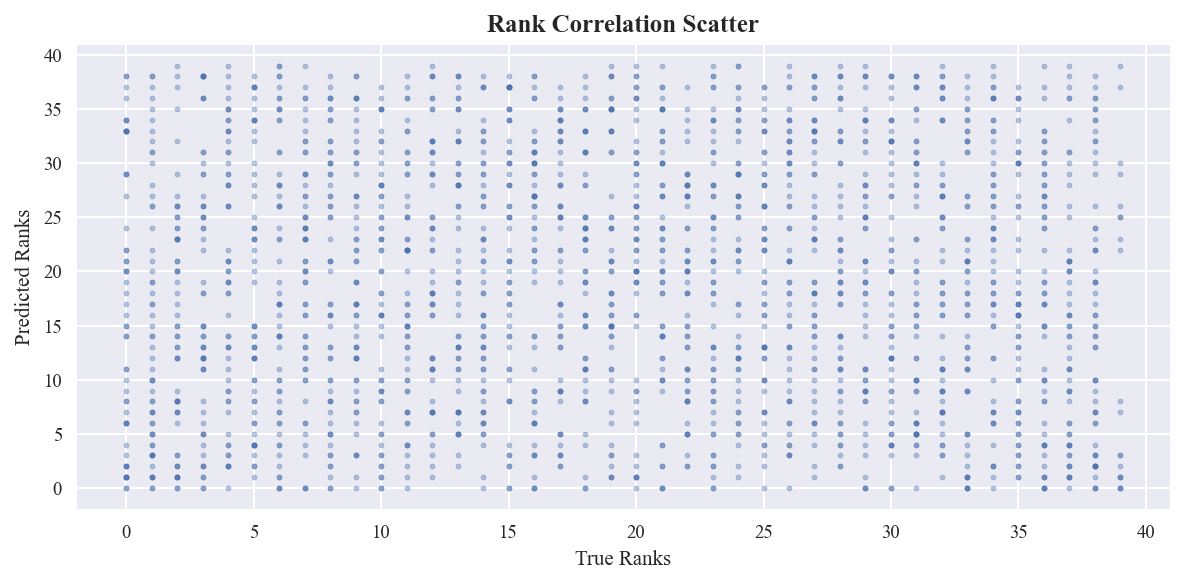

In [13]:
plot_rank_correlation_2(collected['all_true'], collected['all_scores']) 

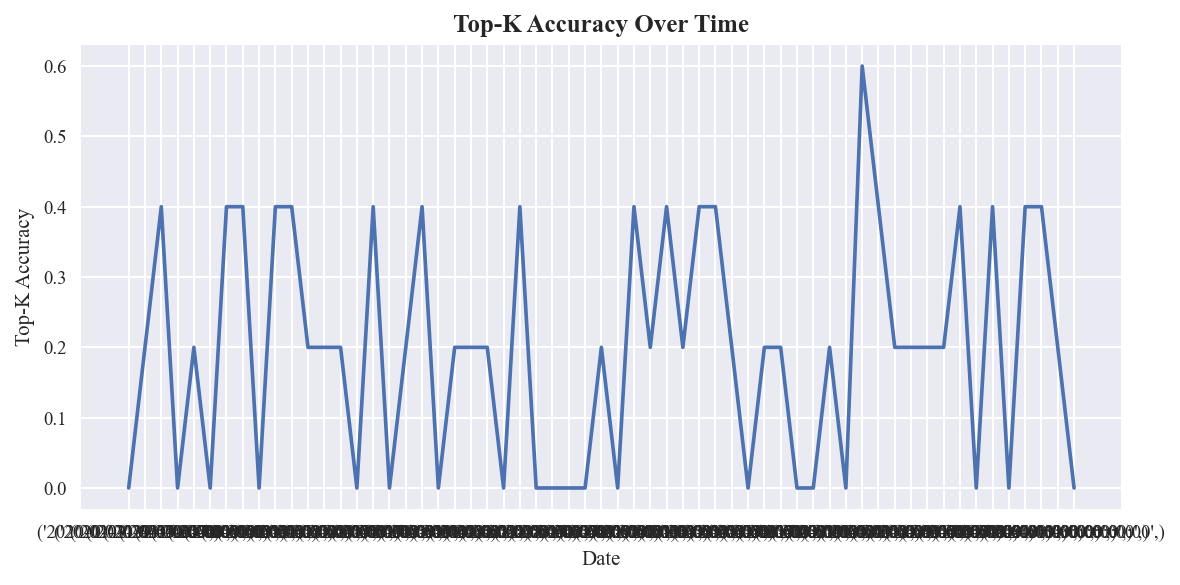

In [14]:
plot_topk_accuracy_over_time(collected['topk_list'], collected['all_dates'])  

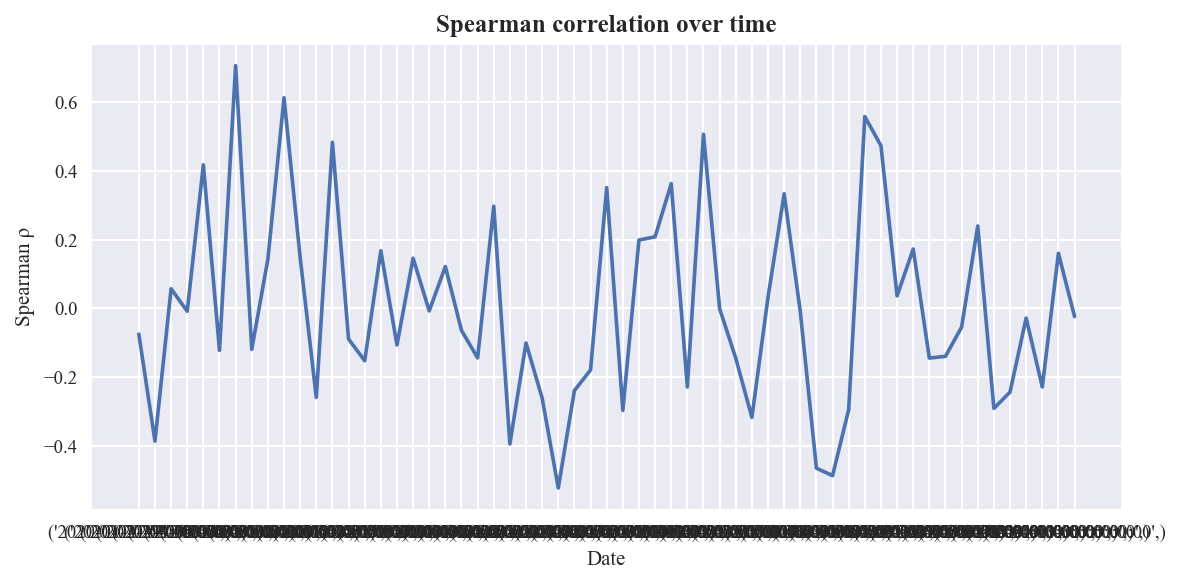

In [15]:
plot_spearman_over_time(collected['spearman_list'], collected['all_dates'])  

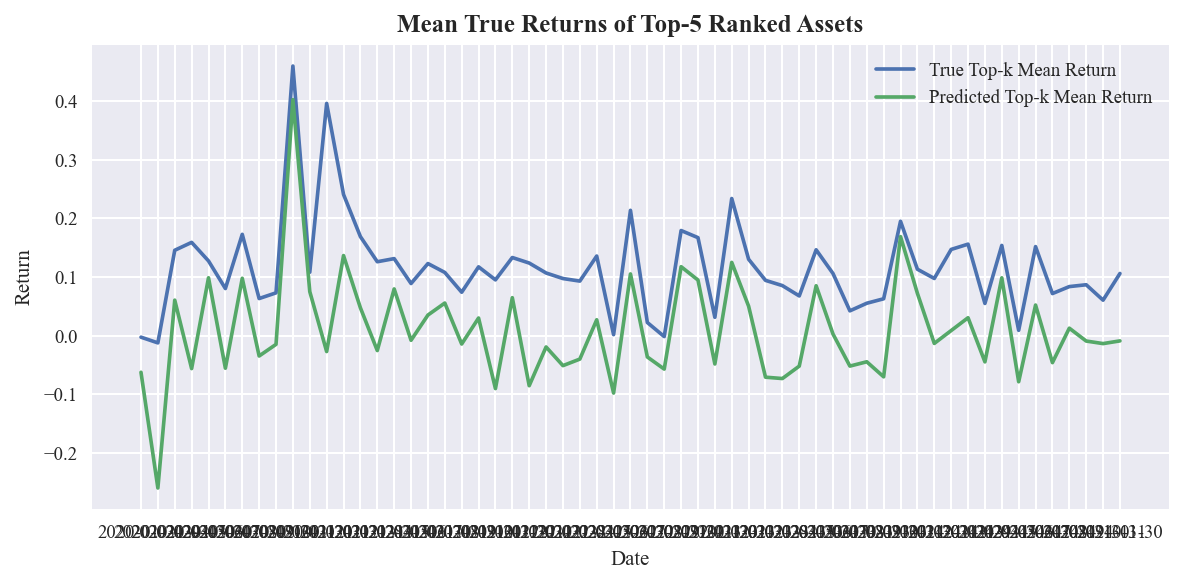

In [16]:
plot_returns_of_top_models(group_table, k=TOP_K) 

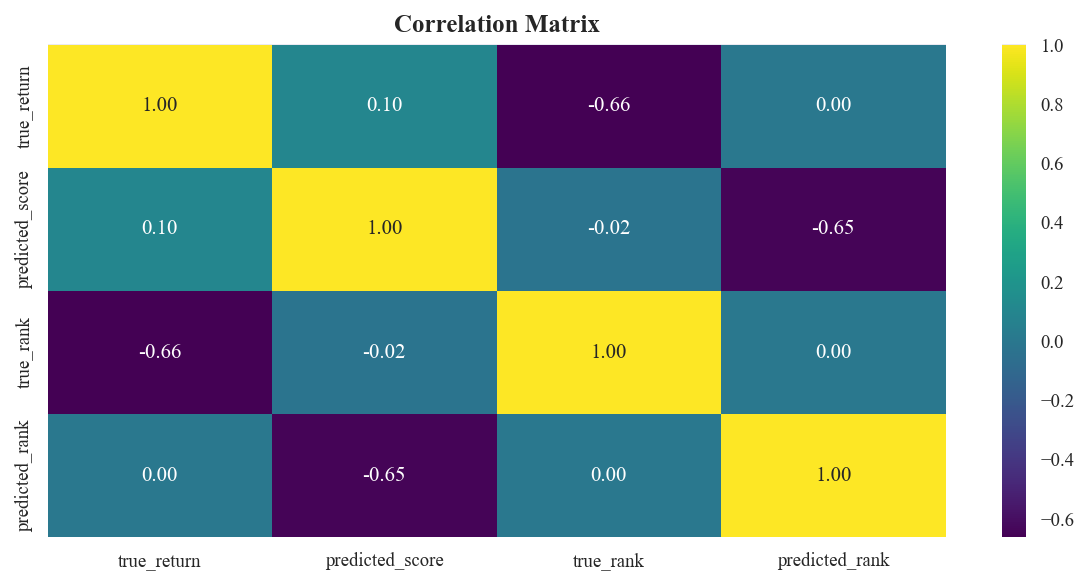

In [17]:
correlation_matrix_scores_returns(group_table) 

In [18]:
feature_importance_df = permutation_importance_listnet(model, optimizer, val_loader, FEATURE_COLS, device = DEVICE, metric="ndcg", k=5, n_repeats=5)
feature_importance_df

,feature,importance_mean,importance_std
0,Momentum,0.197763,0.048223
2,Regime,0.123948,0.057842
1,Volatilite,0.119656,0.094821
3,Beta,0.037430,0.049485
4,Avg_Volume,0.011253,0.035153
5,ADX,0.011037,0.015424


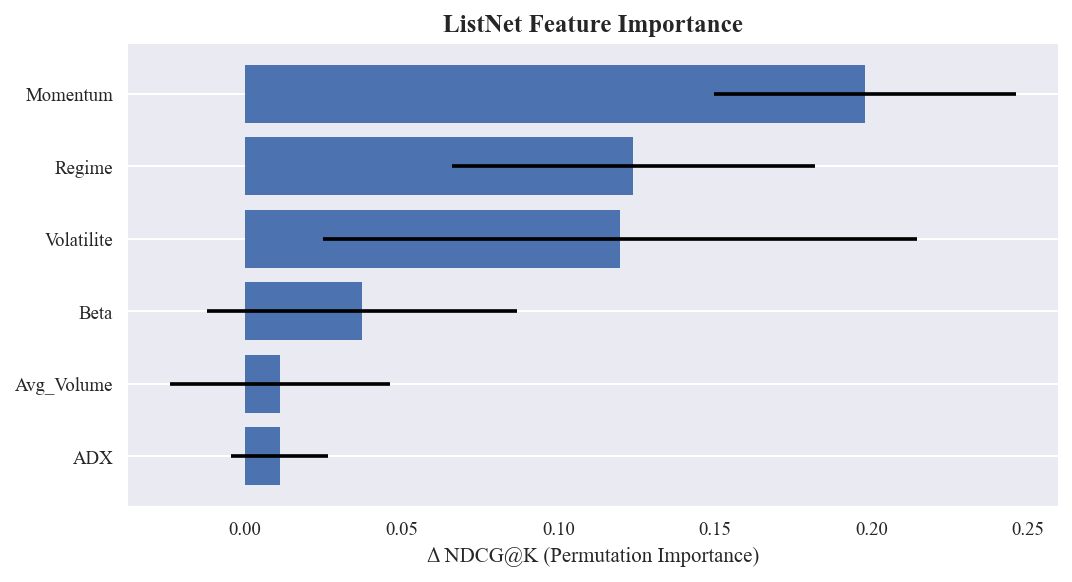

In [19]:
plot_feature_importance(feature_importance_df)

In [44]:
df_cac40_companies = pd.read_csv('cac40_companies.csv')
df_cac40_companies.columns = df_cac40_companies.columns.str.lower()

df_cac40_companies.head()

,company,sector,gicssub-industry,ticker
0,Accor,Consumer Services,"Hotels, Restaurants & Leisure",AC.PA
1,Air Liquide,Basic Materials,Industrial Gases,AI.PA
2,Airbus,Industrials,Aerospace & Defense,AIR.PA
3,ArcelorMittal,Basic Materials,Steel,MT.AS
4,Axa,Financial Services,Life & Health Insurance,CS.PA


In [52]:
df = group_table.merge(df_cac40_companies, left_on = 'ticker', right_on = 'ticker', how = 'left', right_index=False)
df = df[['date', 'ticker', 'company', 'sector', 'gicssub-industry', 'true_return', 'predicted_score', 'true_rank', 'predicted_rank']]
df = df.sort_values(['date', 'predicted_rank'], ascending = True)
df

,date,ticker,company,sector,gicssub-industry,true_return,predicted_score,true_rank,predicted_rank
34,2020-01-31,STMPA.PA,STMicroelectronics,Technology,Semiconductors,-0.034797,0.509313,9,0
16,2020-01-31,ERF.PA,Eurofins Scientific,Healthcare,Biotechnologies,-0.064198,0.295176,16,1
19,2020-01-31,KER.PA,Kering,Consumer Cyclical,"Apparel, Accessories & Luxury Goods",-0.088649,0.057809,23,2
11,2020-01-31,DSY.PA,Dassault Systèmes,Technology,Application Software,-0.093810,0.032986,26,3
36,2020-01-31,TEP.PA,Teleperformance,Communication Services,Outsourcing,-0.030864,0.014415,5,4
...,...,...,...,...,...,...,...,...,...
2312,2024-11-30,SAN.PA,Sanofi,Healthcare,Pharmaceuticals,0.017917,-0.388154,18,35
2282,2024-11-30,ACA.PA,Crédit Agricole,Financial Services,Regional Banks,0.048934,-0.436824,7,36
2285,2024-11-30,BN.PA,Danone,Consumer Defensive,Packaged Foods & Meats,0.007114,-0.444001,23,37
2296,2024-11-30,ENGI.PA,Engie,Utilities,Gas Utilities,0.014915,-0.602113,19,38
